In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle
from astropy.visualization import ZScaleInterval
from astropy.table import Table
from types import SimpleNamespace
import re
from astropy.io import ascii
from astropy import units as u
from astropy.table import Table, vstack, hstack
import line_ratios as lr
from scipy.optimize import curve_fit

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../')
# import src.ifu_tools.line_ratios as lr

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

pf.housestyle_rcparams()

True

In [2]:
rest_lambdas = {
# --- Primary [OIII] and [OII] ---
'oiii5007': 5006.84,
'oiii4959': 4958.91,
'oii3726':  3726.03,
'oii3729':  3728.82,

# --- Hydrogen Balmer Series ---
'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,

# --- Key Diagnostic Lines ---
'oiii4363': 4363.21,
'neiii':    3868.75,

# --- Low-Ionization Lines ---
'nii6583':  6583.45,
'nii6548':  6548.05,
'sii6716':  6716.44,
'sii6731':  6730.82,

# --- Helium Lines ---
'heii4686': 4685.68,
'hei5876':  5875.62,
}
balmer_lambda = {
# 'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,
}
lambda_keys = {
# --- Primary [OIII] and [OII] ---
'oiii5007': r'[OIII] $\lambda$5007',
'oiii4959': r'[OIII] $\lambda$4959',
'oii3726':  r'[OII] $\lambda$3726',
'oii3729':  r'[OII] $\lambda$3729',

# --- Hydrogen Balmer Series ---
'halpha':   r'H$\alpha$',
'hbeta':    r'H$\beta$',
'hgamma':   r'H$\gamma$',
'hdelta':   r'H$\delta$',
'hepsilon': r'H$\epsilon$',
'hzeta':    r'H$\zeta$',
'heta':     r'H$\eta$',

# --- Key Diagnostic Lines ---
'oiii4363': r'[OIII] $\lambda$4363',  # Auroral line
'neiii':    r'[NeIII] $\lambda$3869',

# --- Low-Ionization Lines ---
'nii6583':  r'[NII] $\lambda$6583',
'nii6548':  r'[NII] $\lambda$6548',
'sii6716':  r'[SII] $\lambda$6716',
'sii6731':  r'[SII] $\lambda$6731',

# --- Helium Lines (not forbidden) ---
'heii4686': r'HeII $\lambda$4686',
'hei5876':  r'HeI $\lambda$5876',
}

In [4]:
test = ascii.read('allsources.csv')
tab = test[test['object_id']!= 'STACK']

In [5]:
tab

object_id,ra,dec,z,angdisp,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
28d07m28pt35s-28d53m18pt439s,28.124541666666662,-28.888455277777776,0.3685089804926993,26.18756698942221,nan,nan,8.133519441277883,0.002970077208688108,11.062827619803281,2.277642553607944,717.2840511320709,242.072037707888,0.4127,macs0152m28,4124.469894464831,87.899338157534,35.219154485348156,2.0501406651496796,5006.835951321285,2.000851928624639,47.66104780419961,1185.2825861364677,136.72975380269563,5.898970866095592,1.8880619600846873,4958.900222500991,1.6770166740703585,39.12405443693391,1761.464896696335,1068.6135356727189,29.998235596428906,91.72048342399984,3725.300846892047,5.449503026807009,184.65485291083476,2884.5577145722427,1618.3931634975047,49.243829643832576,138.90878074330303,3728.766711514383,5.449503026807009,184.51668935249157,2409.7560001934326,91.49395579602738,63.31686

(array([0.11094891, 0.        , 0.        , 0.05547445, 0.05547445,
        0.05547445, 0.38832117, 0.27737226, 0.88759124, 0.77664234,
        1.49781022, 1.22043796, 0.94306569, 0.33284672, 0.33284672,
        0.22189781, 0.27737226, 0.11094891, 0.05547445]),
 array([0.        , 0.13157895, 0.26315789, 0.39473684, 0.52631579,
        0.65789474, 0.78947368, 0.92105263, 1.05263158, 1.18421053,
        1.31578947, 1.44736842, 1.57894737, 1.71052632, 1.84210526,
        1.97368421, 2.10526316, 2.23684211, 2.36842105, 2.5       ]),
 <BarContainer object of 19 artists>)

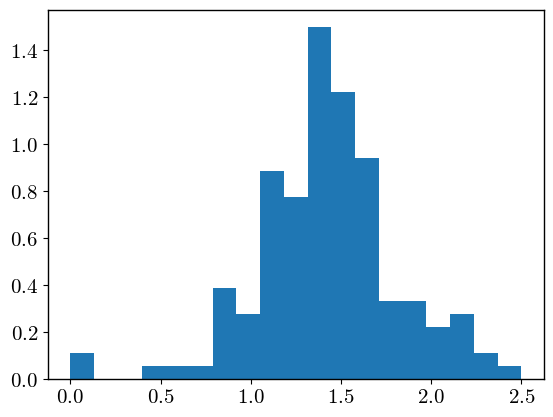

In [76]:
rat = tab['oii3729_flux']/tab['oii3726_flux']
mask = np.isfinite(rat)
plt.hist(rat[mask], bins=np.linspace(0,2.5,20), density=True)

(array([0.08507463, 0.        , 0.02835821, 0.09925373, 0.05671642,
        0.29776119, 0.38283582, 0.26940299, 0.17014925, 0.19850746,
        0.11343284, 0.0141791 , 0.02835821, 0.04253731, 0.        ,
        0.02835821, 0.02835821, 0.04253731, 0.0141791 ]),
 array([ 0.        ,  0.52631579,  1.05263158,  1.57894737,  2.10526316,
         2.63157895,  3.15789474,  3.68421053,  4.21052632,  4.73684211,
         5.26315789,  5.78947368,  6.31578947,  6.84210526,  7.36842105,
         7.89473684,  8.42105263,  8.94736842,  9.47368421, 10.        ]),
 <BarContainer object of 19 artists>)

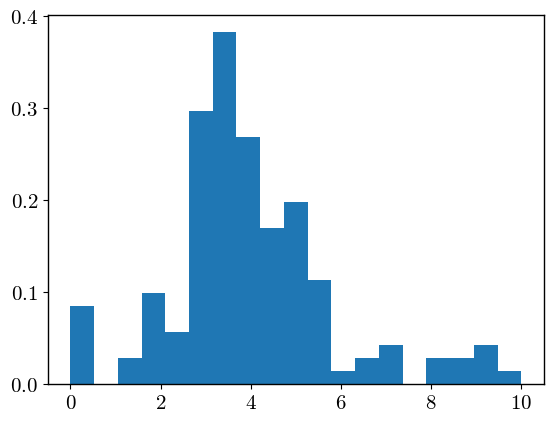

In [77]:
rat = tab['oiii5007_flux']/tab['oiii4959_flux']
mask1 = np.isfinite(rat)
plt.hist(rat[mask1], bins=np.linspace(0,10,20), density=True)

(array([0.08860759, 0.17721519, 0.22151899, 0.48734177, 0.53164557,
        0.97468354, 3.10126582, 0.93037975, 0.22151899, 0.08860759,
        0.0443038 , 0.0443038 , 0.0443038 , 0.0443038 ]),
 array([0.        , 0.14285714, 0.28571429, 0.42857143, 0.57142857,
        0.71428571, 0.85714286, 1.        , 1.14285714, 1.28571429,
        1.42857143, 1.57142857, 1.71428571, 1.85714286, 2.        ]),
 <BarContainer object of 14 artists>)

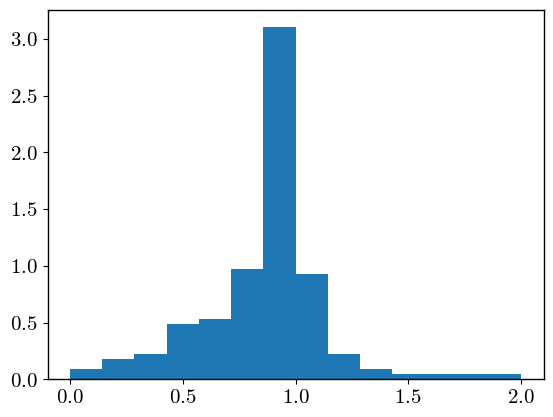

In [78]:
R23 = (tab['oiii5007_flux'] + tab['oiii4959_flux'] +  tab['oii3729_flux'] + tab['oii3726_flux'])/tab['hbeta_flux']
mask2 = np.isfinite(R23)
plt.hist(np.log10(R23[mask2]), density=True, bins=np.linspace(0,2,15))

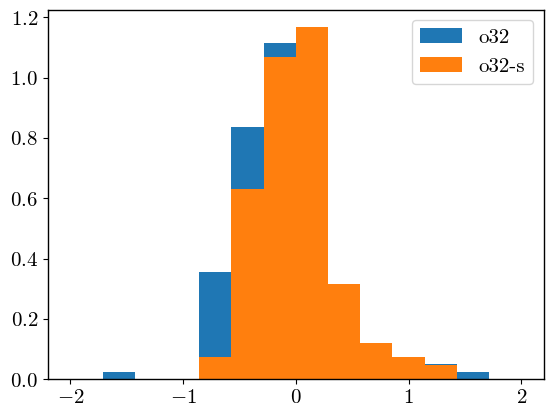

In [79]:
O32 = (tab['oiii5007_flux'] + tab['oiii4959_flux'])/(tab['oii3729_flux'] + tab['oii3726_flux'])
O32_s = (tab['oiii5007_flux'])/(tab['oii3729_flux'])
mask3 = np.isfinite(O32)
mask_s = np.isfinite(O32_s)
plt.hist(np.log10(O32[mask3]), density=True, bins=np.linspace(-2,2,15), label=r'o32')
plt.hist(np.log10(O32_s[mask_s]), density=True, bins=np.linspace(-2,2,15), label=r'o32-s')
plt.legend()

True

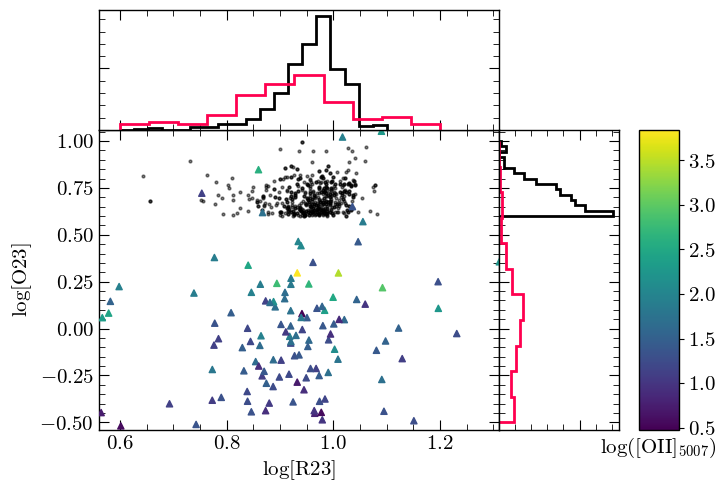

In [119]:
fig, ax = pf.create_plot()
ax.set_xlabel(r'$\log[\mathrm{R23}]$')
ax.set_ylabel(r'$\log[\mathrm{O23}]$')


ax1 = fig.add_axes([1,0,0.3,1], sharey=ax)
plt.setp(ax1.get_yticklabels(), visible=False)
plt.setp(ax1.get_xticklabels(), visible=False)
ax2 = fig.add_axes([0,1,1,0.4], sharex=ax)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.setp(ax2.get_yticklabels(), visible=False)

cax = fig.add_axes([1.35,0,0.1,1])
cax.set_xlabel(r'$\log(\mathrm{[OII]}_{5007})$')

jiang_table = ascii.read('jiang_colorplot_data.csv')
O32_j = jiang_table['y']
R23_j = jiang_table['x']
cm = np.isfinite(tab['oiii5007_ew'])

ax.scatter(R23_j, O32_j, c='k', s=4, label='Jiang+ (2019)', alpha=0.5)
scatter = ax.scatter(np.log10(R23)[cm],np.log10(O32_s)[cm], s=20, marker='^',zorder=10, c=np.log10(tab['oiii5007_ew'])[cm])
cbar = fig.colorbar(scatter, ax=ax, cax=cax)

xlims = np.array([0.5,1.25])
ylims = np.array([-0.6,1])

ax.set_xlim(xlims+0.06)
ax.set_ylim(ylims+0.06)


ax1.hist(O32_j, bins=np.linspace(0.6,1,15), density=True, orientation='horizontal', histtype='step', lw=2, ec='k')
ax2.hist(R23_j, bins=np.linspace(0.6,1.1,20), density=True, orientation='vertical', histtype='step', lw=2, ec='k')

ax1.hist(np.log10(O32_s), bins=np.linspace(-0.5,1,12), density=True, orientation='horizontal', histtype='step', lw=2, ec='#ff004f')
ax2.hist(np.log10(R23), bins=np.linspace(0.6,1.2,12), density=True, orientation='vertical', histtype='step', lw=2, ec='#ff004f')

pf.fix_plot([ax,ax1,ax2])
